# Neural MPLE with similarity-weighted neighbor averages for DGL Fraud Yelp

This notebook combines the previous similarity-weighted graph signal with a neural external field.

The main fitted model is

$$
\mathbb P_{\beta,\theta}(\sigma_i=1\mid \sigma_{-i},X,G)
=
\operatorname{logit}^{-1}(2h_i),
$$

where

$$
h_i
=
\sum_{r=1}^3 \beta_r \overline S^{\,w}_{ir}
+
2b_\theta(X_i).
$$

Here

$$
\overline S^{\,w}_{ir}
=
\frac{
\sum_{j:(j,i)\in E_r}w^{(r)}_{ij}\sigma_j^{\mathrm{obs}}
}{
\sum_{j:(j,i)\in E_r}w^{(r)}_{ij}\mathbf 1\{j\text{ observed}\}+\varepsilon
}.
$$

The default similarity weight is feature-RBF similarity,

$$
w^{(r)}_{ij}
=
\exp\left(
-\frac{\|X_i-X_j\|_2^2}{2\tau_r^2}
\right),
$$

with $\tau_r$ estimated separately for each relation by the median edgewise feature distance.

This keeps the graph term interpretable through $\beta_1,\beta_2,\beta_3$, while replacing the linear external field $X_i^\top\gamma$ by a neural network $b_\theta(X_i)$.

The notebook also includes an optional fully neural local-field model

$$
h_i=f_\theta(X_i,\overline S^w_{i1},\overline S^w_{i2},\overline S^w_{i3}),
$$

but that version no longer preserves interpretable $\beta_r$'s.


In [1]:
# If needed, install dependencies first. Restart the runtime after this cell finishes.
# This notebook uses DGL only for the FraudYelpDataset/graph object, so use the DGL 2.4 wheel directly.
# %pip uninstall -y -q dgl torchdata
# %pip install -q --no-deps dgl==2.4.0 -f https://data.dgl.ai/wheels/torch-2.4/repo.html


In [6]:
import math
import random
import copy
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist


import dgl
from dgl.data import FraudYelpDataset


SEED = 717

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load Fraud Yelp

The original labels are $y_i\in\{0,1\}$. We convert them to spins by

$$
\sigma_i=2y_i-1.
$$


In [7]:
dataset = FraudYelpDataset(
    random_seed=SEED,
    train_size=0.7,
    val_size=0.1,
    verbose=True,
)

g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [8]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when the graph has multiple node types.")
        ntype = g.ntypes[0]

    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value


ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()

train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [
        int(train_mask.sum()),
        int(val_mask.sum()),
        int(test_mask.sum()),
        int(y01.numel()),
    ],
    "positives_label_1": [
        int(y01[train_mask].sum()),
        int(y01[val_mask].sum()),
        int(y01[test_mask].sum()),
        int(y01.sum()),
    ],
})
summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [9]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]

BETA_LABELS = [
    "beta_1: net_rur",
    "beta_2: net_rsr",
    "beta_3: net_rtr",
]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


## Standardize node features

The neural network receives standardized features. The mean and standard deviation are computed from training nodes only.


In [10]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    X_std = (X - mean) / std
    return X_std, mean, std


X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)

print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Similarity-weighted neighbor averages

By default, only training labels are treated as observed:

$$
\sigma_j^{\mathrm{obs}}
=
\begin{cases}
\sigma_j, & j\in\mathcal T,\\
0, & j\notin\mathcal T.
\end{cases}
$$

This avoids using validation/test labels inside the graph covariates.


In [11]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic only

SIMILARITY_MODE = "cosine_positive"  # one of {"rbf_features", "cosine_positive"}

# Chunk size controls memory use. Reduce this if you run out of memory.
EDGE_CHUNK_SIZE = 500_000

# Number of edges sampled per relation to estimate the RBF scale tau_r.
TAU_SAMPLE_SIZE = 200_000

# If True, denominator averages only over observed-label source nodes.
DENOMINATOR_USES_ONLY_OBSERVED_LABELS = True


@torch.no_grad()
def estimate_relation_taus_from_edge_samples(
    g,
    X_for_similarity,
    edge_types,
    sample_size=200_000,
    seed=717,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    rng = np.random.default_rng(seed)
    X_dev = X_for_similarity.to(device).float()

    tau_values = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        m = src.numel()

        if m == 0:
            tau_values.append(1.0)
            continue

        k = min(sample_size, m)
        sample_idx = rng.choice(m, size=k, replace=False)

        src_s = src[sample_idx].to(device)
        dst_s = dst[sample_idx].to(device)

        diff = X_dev[src_s] - X_dev[dst_s]
        dist = diff.pow(2).sum(dim=1).sqrt()

        tau = torch.median(dist).item()
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = float(dist.mean().item())
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = 1.0

        tau_values.append(float(tau))

    return torch.tensor(tau_values, dtype=torch.float32)


@torch.no_grad()
def edge_similarity_weights(X_dev, src, dst, mode, tau=None):
    if mode == "rbf_features":
        if tau is None:
            raise ValueError("tau is required for rbf_features similarity.")
        diff = X_dev[src] - X_dev[dst]
        dist2 = diff.pow(2).sum(dim=1)
        w = torch.exp(-dist2 / (2.0 * float(tau) ** 2))
        return w

    if mode == "cosine_positive":
        x_src = X_dev[src]
        x_dst = X_dev[dst]
        numerator = (x_src * x_dst).sum(dim=1)
        denom = x_src.norm(dim=1).clamp_min(1e-12) * x_dst.norm(dim=1).clamp_min(1e-12)
        cosine = numerator / denom
        return torch.clamp(cosine, min=0.0, max=1.0)

    raise ValueError("SIMILARITY_MODE must be one of {'rbf_features', 'cosine_positive'}.")


@torch.no_grad()
def compute_similarity_weighted_neighbor_averages(
    g,
    sigma_all,
    observed_mask,
    X_for_similarity,
    edge_types,
    similarity_mode="rbf_features",
    tau_values=None,
    denominator_observed_only=True,
    chunk_size=500_000,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n = sigma_all.numel()

    X_dev = X_for_similarity.to(device).float()
    sigma_dev = sigma_all.to(device).float()
    obs_dev = observed_mask.to(device).bool()

    avg_columns = []
    numerator_columns = []
    denominator_columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        m = src_cpu.numel()

        numerator = torch.zeros(n, dtype=torch.float32, device=device)
        denominator = torch.zeros(n, dtype=torch.float32, device=device)

        tau_r = None
        if similarity_mode == "rbf_features":
            tau_r = float(tau_values[r])

        for start in range(0, m, chunk_size):
            end = min(start + chunk_size, m)

            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)

            w = edge_similarity_weights(
                X_dev,
                src,
                dst,
                mode=similarity_mode,
                tau=tau_r,
            )

            obs_src = obs_dev[src].float()

            weighted_spin = w * obs_src * sigma_dev[src]
            numerator.index_add_(0, dst, weighted_spin)

            if denominator_observed_only:
                denominator_increment = w * obs_src
            else:
                denominator_increment = w

            denominator.index_add_(0, dst, denominator_increment)

        avg = numerator / denominator.clamp_min(1e-12)
        avg = torch.where(denominator > 0, avg, torch.zeros_like(avg))

        avg_columns.append(avg.cpu())
        numerator_columns.append(numerator.cpu())
        denominator_columns.append(denominator.cpu())

    Sbar_w = torch.stack(avg_columns, dim=1)
    N_w = torch.stack(numerator_columns, dim=1)
    D_w = torch.stack(denominator_columns, dim=1)

    return Sbar_w, N_w, D_w


## Estimate relation-specific RBF bandwidths


In [12]:
tau_values = estimate_relation_taus_from_edge_samples(
    g=g,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    sample_size=TAU_SAMPLE_SIZE,
    seed=SEED,
    device=device,
)

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "tau_r": tau_values.numpy(),
})


,edge_type,tau_r
0,net_rur,6.746763
1,net_rsr,7.590441
2,net_rtr,7.569873


## Build $\overline S^{\,w}$


In [13]:
Sbar_w, numerator_w, denominator_w = compute_similarity_weighted_neighbor_averages(
    g=g,
    sigma_all=sigma_all,
    observed_mask=SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    similarity_mode=SIMILARITY_MODE,
    tau_values=tau_values,
    denominator_observed_only=DENOMINATOR_USES_ONLY_OBSERVED_LABELS,
    chunk_size=EDGE_CHUNK_SIZE,
    device=device,
)

pd.DataFrame(Sbar_w[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-0.373472,0.519389,-1.0,-1.000000,0.000000,0.000000,1.0
net_rsr,32167.0,-0.714389,0.294284,-1.0,-0.901667,-0.797873,-0.633094,1.0
net_rtr,32167.0,-0.690636,0.399517,-1.0,-1.000000,-0.843196,-0.528417,1.0


In [14]:
neighbor_summary = pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "mean_weighted_denominator_train": denominator_w[train_mask].mean(dim=0).numpy(),
    "median_weighted_denominator_train": denominator_w[train_mask].median(dim=0).values.numpy(),
    "fraction_train_with_no_observed_weighted_neighbors": (denominator_w[train_mask] <= 0).float().mean(dim=0).numpy(),
})

neighbor_summary


,edge_type,mean_weighted_denominator_train,median_weighted_denominator_train,fraction_train_with_no_observed_weighted_neighbors
0,net_rur,0.418040,0.000000,0.590108
1,net_rsr,13.915053,12.457725,0.002394
2,net_rtr,2.445546,1.973895,0.025150


## Model 1: similarity-weighted graph field + neural external field

The main model is

$$
h_i
=
\sum_{r=1}^3\beta_r\overline S^{\,w}_{ir}
+
2b_\theta(X_i).
$$

This is the direct analogue of the previous linear model, with $X_i^\top\gamma$ replaced by $b_\theta(X_i)$.

Set

```python
BETA_CONSTRAINT = "unconstrained"
```

to allow $\beta_r\in\mathbb R$, or

```python
BETA_CONSTRAINT = "nonnegative"
```

to enforce $\beta_r\ge 0$.


In [15]:
BETA_CONSTRAINT = "unconstrained"  # one of {"unconstrained", "nonnegative"}


def inverse_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))


class SimilarityWeightedNeuralExternalFieldMPLE(nn.Module):
    def __init__(
        self,
        n_features,
        n_relations=3,
        hidden=64,
        dropout=0.2,
        beta_constraint="unconstrained",
    ):
        super().__init__()

        if beta_constraint not in {"unconstrained", "nonnegative"}:
            raise ValueError("beta_constraint must be 'unconstrained' or 'nonnegative'.")

        self.beta_constraint = beta_constraint

        if beta_constraint == "unconstrained":
            self.beta_param = nn.Parameter(torch.zeros(n_relations))
        else:
            beta_init = torch.full((n_relations,), 1e-4)
            self.beta_param = nn.Parameter(inverse_softplus(beta_init))

        self.field_net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    @property
    def beta(self):
        if self.beta_constraint == "unconstrained":
            return self.beta_param
        return F.softplus(self.beta_param)

    def field(self, X):
        return self.field_net(X).squeeze(-1)

    def logits(self, Sbar_w, X):
        b = self.field(X)
        h = Sbar_w @ self.beta + 2.0 * b
        return 2.0 * h

    def forward(self, Sbar_w, X):
        return self.logits(Sbar_w, X)


## Metrics and utilities


In [16]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out


@torch.no_grad()
def predict_prob(model, Sbar_w, X, device):
    model.eval()
    logits = model(Sbar_w.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()


def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)

    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t = 0.5
    best_value = -np.inf

    for t in thresholds:
        pred = (score >= t).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'.")

        if value > best_value:
            best_value = value
            best_t = float(t)

    return best_t, best_value


def evaluate_splits(model, Sbar_w, X, y01, masks, threshold, device):
    prob = predict_prob(model, Sbar_w, X, device).numpy()
    y_np = y01.numpy().astype(int)

    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)

    return pd.DataFrame(rows)


## Train neural external-field model

The ordinary pseudo-likelihood uses `USE_POS_WEIGHT = False`.

If the target is minority-class F1 rather than parameter interpretation, try `USE_POS_WEIGHT = True`. This changes the objective into a weighted pseudo-likelihood classifier.


In [17]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_similarity_weighted_neural_external_field_mple(
    Sbar_w,
    X,
    y01,
    train_mask,
    val_mask,
    relation_names=None,
    hidden=64,
    dropout=0.2,
    beta_constraint="unconstrained",
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
    seed=None,
    verbose=True,
):
    """Train HM weighted neural MPLE.

    This version supports any number of relation columns, so it can be reused for
    edge-type ablations such as only net_rur or net_rur + net_rsr.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if seed is not None:
        set_all_seeds(seed)

    if relation_names is None:
        relation_names = [f"rel_{i}" for i in range(Sbar_w.shape[1])]
    if len(relation_names) != Sbar_w.shape[1]:
        raise ValueError("relation_names must have one entry per column of Sbar_w.")

    S_dev = Sbar_w.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = SimilarityWeightedNeuralExternalFieldMPLE(
        n_features=X.shape[1],
        n_relations=Sbar_w.shape[1],
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        beta = model.beta
        beta_penalty = 0.5 * l2_beta * (beta @ beta)

        loss = train_loss_data + beta_penalty
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

        beta_values = model.beta.detach().cpu().numpy()

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "l2_beta_penalty": float(beta_penalty.detach().cpu().item()),
            "beta_norm": float(model.beta.detach().norm().cpu()),
        }
        for name, value in zip(relation_names, beta_values):
            row[f"beta_{name}"] = float(value)
        history.append(row)

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose and epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} "
                f"beta={beta_values}"
            )

        if bad_epochs >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
        "beta_constraint": beta_constraint,
        "l2_beta": l2_beta,
        "relations": relation_names,
        "seed": seed,
    }

    return model, history_df, fit_info


In [18]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_similarity_weighted_neural_external_field_mple(
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden=64,
    dropout=0.2,
    beta_constraint=BETA_CONSTRAINT,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.65499 val_loss=0.65528 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.35046 val_loss=0.34804 beta=[0.04025542 0.0284373  0.02732798]
epoch= 100 train_loss=0.32053 val_loss=0.32142 beta=[0.07898574 0.0513777  0.04821401]
epoch= 150 train_loss=0.30035 val_loss=0.30596 beta=[0.11780739 0.07565317 0.07008123]
epoch= 200 train_loss=0.28568 val_loss=0.29472 beta=[0.15625808 0.10066029 0.09240186]
epoch= 250 train_loss=0.27490 val_loss=0.28543 beta=[0.19442706 0.12624823 0.11488597]
epoch= 300 train_loss=0.26550 val_loss=0.27676 beta=[0.23218133 0.15226763 0.13737658]
epoch= 350 train_loss=0.25714 val_loss=0.26903 beta=[0.26935026 0.17848441 0.15957302]
epoch= 400 train_loss=0.24904 val_loss=0.26248 beta=[0.30580267 0.20461509 0.18117733]
epoch= 450 train_loss=0.24114 val_loss=0.25612 beta=[0.3415261  0.23057792 0.20218675]
epoch= 500 train_loss=0.23326 val_loss=0.24947 beta=[0.37638623 0.25636294 0.22251014]
epoch= 550 train_loss=0.22505 val_loss=0.24247 beta=[0.410

{'best_epoch': 992,
 'best_val_loss': 0.2024064064025879,
 'pos_weight': None,
 'beta_constraint': 'unconstrained'}

In [19]:
history_df.tail()


,epoch,train_loss,val_loss,beta_1,beta_2,beta_3,beta_norm
995,995,0.176138,0.202518,0.675288,0.485004,0.378307,0.913433
996,996,0.176099,0.202465,0.675828,0.485411,0.378534,0.914142
997,997,0.176069,0.202454,0.676366,0.485815,0.378759,0.914847
998,998,0.176065,0.202455,0.676905,0.486219,0.378985,0.915554
999,999,0.176064,0.202405,0.677443,0.486624,0.379210,0.916260


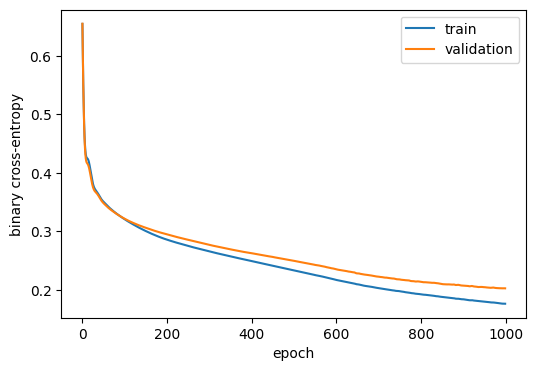

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


## Estimated $\beta$'s


In [21]:
with torch.no_grad():
    beta_hat = model.beta.detach().cpu()
    beta_param_hat = model.beta_param.detach().cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_beta": beta_hat.numpy(),
    "internal_beta_param": beta_param_hat.numpy(),
    "constraint": BETA_CONSTRAINT,
})

beta_df


,parameter,estimate_beta,internal_beta_param,constraint
0,beta_1: net_rur,0.673670,0.673670,unconstrained
1,beta_2: net_rsr,0.483777,0.483777,unconstrained
2,beta_3: net_rtr,0.377615,0.377615,unconstrained


## Learned neural external field $b_\theta(X_i)$


In [22]:
@torch.no_grad()
def compute_learned_field(model, X, device):
    model.eval()
    b = model.field(X.to(device).float())
    return b.detach().cpu()


b_hat = compute_learned_field(model, X, device)

field_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "mean_b_hat": [
        float(b_hat[train_mask].mean()),
        float(b_hat[val_mask].mean()),
        float(b_hat[test_mask].mean()),
        float(b_hat.mean()),
    ],
    "std_b_hat": [
        float(b_hat[train_mask].std(unbiased=False)),
        float(b_hat[val_mask].std(unbiased=False)),
        float(b_hat[test_mask].std(unbiased=False)),
        float(b_hat.std(unbiased=False)),
    ],
})

field_summary


,split,mean_b_hat,std_b_hat
0,train,-0.328101,0.446170
1,validation,-0.320725,0.436042
2,test,-0.328117,0.436329
3,all,-0.327367,0.443218


In [23]:
pd.DataFrame({
    "y": y01.numpy(),
    "sigma": sigma_all.numpy(),
    "b_hat": b_hat.numpy(),
    "train": train_mask.numpy(),
    "validation": val_mask.numpy(),
    "test": test_mask.numpy(),
}).groupby("y")["b_hat"].describe()


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,39277.0,-0.424327,0.378236,-2.483375,-0.643665,-0.397789,-0.172086,1.102917
1,6677.0,0.242996,0.360366,-1.137949,-0.003394,0.238806,0.486996,1.501051


## Prediction and evaluation


In [24]:
masks = {
    "train": train_mask,
    "validation": val_mask,
    "test": test_mask,
}

metrics_05 = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=0.5,
    device=device,
)

metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.932540,0.797480,0.902647,0.606221,0.725316,27132,309,1861,2865,0.960902,0.863188,train
1,0.5,4595,0.141676,0.919260,0.763149,0.825581,0.545315,0.656799,3869,75,296,355,0.938100,0.790322,validation
2,0.5,9192,0.141427,0.924282,0.770538,0.858670,0.556154,0.675070,7773,119,577,723,0.940272,0.794440,test


In [25]:
prob = predict_prob(model, Sbar_w, X, device).numpy()
y_np = y01.numpy().astype(int)

val_idx = val_mask.numpy().astype(bool)

best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="balanced_accuracy",
)

best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="f1",
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.113 value: 0.865465207217481
Best validation threshold for F1: 0.359 value: 0.7186495176848875


In [26]:
metrics_val_balacc = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_balacc,
    device=device,
)

metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.113,32167,0.146921,0.847141,0.884923,0.489460,0.938426,0.643360,22815,4626,291,4435,0.960902,0.863188,train
1,0.113,4595,0.141676,0.829597,0.865465,0.450151,0.915515,0.603544,3216,728,55,596,0.938100,0.790322,validation
2,0.113,9192,0.141427,0.832245,0.861185,0.453210,0.901538,0.603191,6478,1414,128,1172,0.940272,0.794440,test


In [27]:
metrics_val_f1 = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_f1,
    device=device,
)

metrics_val_f1


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.359,32167,0.146921,0.938322,0.857356,0.820477,0.742700,0.779653,26673,768,1216,3510,0.960902,0.863188,train
1,0.359,4595,0.141676,0.923830,0.824809,0.753794,0.686636,0.718650,3798,146,204,447,0.938100,0.790322,validation
2,0.359,9192,0.141427,0.922541,0.817392,0.754325,0.670769,0.710098,7608,284,428,872,0.940272,0.794440,test


## Compare unconstrained and nonnegative $\beta$

This fits both versions using the same similarity-weighted neighbor averages.


In [24]:
def fit_and_evaluate_beta_constraint(beta_constraint):
    model_c, history_c, info_c = train_similarity_weighted_neural_external_field_mple(
        Sbar_w=Sbar_w,
        X=X,
        y01=y01,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden=64,
        dropout=0.2,
        beta_constraint=beta_constraint,
        lr=1e-3,
        weight_decay=1e-4,
        l2_beta=1e-4,
        max_epochs=1000,
        patience=100,
        use_pos_weight=USE_POS_WEIGHT,
        device=device,
    )

    prob_c = predict_prob(model_c, Sbar_w, X, device).numpy()

    t_c, val_balacc_c = select_threshold(
        y_true=y_np[val_idx],
        score=prob_c[val_idx],
        objective="balanced_accuracy",
    )

    metrics_c = evaluate_splits(
        model=model_c,
        Sbar_w=Sbar_w,
        X=X,
        y01=y01,
        masks={"validation": val_mask, "test": test_mask},
        threshold=t_c,
        device=device,
    )

    beta_c = model_c.beta.detach().cpu().numpy()

    metrics_c["constraint"] = beta_constraint
    metrics_c["selected_threshold"] = t_c
    metrics_c["best_epoch"] = info_c["best_epoch"]
    metrics_c["best_val_loss"] = info_c["best_val_loss"]

    for k, label in enumerate(["beta_1", "beta_2", "beta_3"]):
        metrics_c[label] = beta_c[k]

    return model_c, history_c, info_c, metrics_c


model_unconstrained, history_unconstrained, info_unconstrained, metrics_unconstrained = fit_and_evaluate_beta_constraint("unconstrained")
model_nonnegative, history_nonnegative, info_nonnegative, metrics_nonnegative = fit_and_evaluate_beta_constraint("nonnegative")

comparison_df = pd.concat([metrics_unconstrained, metrics_nonnegative], ignore_index=True)
comparison_df


epoch=   0 train_loss=0.73984 val_loss=0.74153 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.34668 val_loss=0.34629 beta=[0.03796459 0.02636061 0.02542549]
epoch= 100 train_loss=0.32115 val_loss=0.32314 beta=[0.07447791 0.04556242 0.04278576]
epoch= 150 train_loss=0.30245 val_loss=0.30809 beta=[0.1120698  0.0667282  0.06179031]
epoch= 200 train_loss=0.28993 val_loss=0.29800 beta=[0.14990544 0.08948898 0.08206451]
epoch= 250 train_loss=0.27986 val_loss=0.28926 beta=[0.18768997 0.11345273 0.10319345]
epoch= 300 train_loss=0.27047 val_loss=0.28088 beta=[0.22506776 0.13805711 0.1245268 ]
epoch= 350 train_loss=0.26156 val_loss=0.27309 beta=[0.2618574  0.16292974 0.14569272]
epoch= 400 train_loss=0.25306 val_loss=0.26550 beta=[0.2979616  0.18786207 0.16649015]
epoch= 450 train_loss=0.24517 val_loss=0.25846 beta=[0.33334982 0.21277331 0.18684867]
epoch= 500 train_loss=0.23790 val_loss=0.25204 beta=[0.36798197 0.23745112 0.2065431 ]
epoch= 550 train_loss=0.23095 val_loss=0.24592 beta=[0.401

,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,...,roc_auc,average_precision,split,constraint,selected_threshold,best_epoch,best_val_loss,beta_1,beta_2,beta_3
0,0.127,4595,0.141676,0.840044,0.861931,0.466292,0.892473,0.612546,3279,665,...,0.937064,0.785925,validation,unconstrained,0.127,999,0.206028,0.671052,0.465516,0.365389
1,0.127,9192,0.141427,0.845518,0.861204,0.475166,0.883077,0.617869,6624,1268,...,0.940473,0.792233,test,unconstrained,0.127,999,0.206028,0.671052,0.465516,0.365389
2,0.150,4595,0.141676,0.815887,0.801688,0.419621,0.781874,0.546137,3240,704,...,0.879793,0.639056,validation,nonnegative,0.150,997,0.265959,0.000297,0.000241,0.000235
3,0.150,9192,0.141427,0.825500,0.796860,0.433099,0.756923,0.550952,6604,1288,...,0.884164,0.649438,test,nonnegative,0.150,997,0.265959,0.000297,0.000241,0.000235


## Local field decomposition

For each node,

$$
h_i
=
\underbrace{\sum_{r=1}^3\beta_r\overline S^w_{ir}}_{\text{similarity-weighted graph field}}
+
\underbrace{2b_\theta(X_i)}_{\text{neural external field}}.
$$


In [25]:
@torch.no_grad()
def local_field_decomposition(model, Sbar_w, X, y01, train_mask, val_mask, test_mask, device):
    model.eval()

    S_dev = Sbar_w.to(device).float()
    X_dev = X.to(device).float()

    beta = model.beta.detach()
    graph_field = S_dev @ beta
    neural_external_field = 2.0 * model.field(X_dev)
    total_h = graph_field + neural_external_field
    prob = torch.sigmoid(2.0 * total_h)

    return pd.DataFrame({
        "graph_field": graph_field.cpu().numpy(),
        "neural_external_field_2b": neural_external_field.cpu().numpy(),
        "total_h": total_h.cpu().numpy(),
        "prob_label_1": prob.cpu().numpy(),
        "label": y01.numpy(),
        "train": train_mask.numpy(),
        "validation": val_mask.numpy(),
        "test": test_mask.numpy(),
    })


field_decomp_df = local_field_decomposition(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    device=device,
)

field_decomp_df.head()


,graph_field,neural_external_field_2b,total_h,prob_label_1,label,train,validation,test
0,-0.483777,-0.435677,-0.919454,0.137181,0,False,True,False
1,0.000000,-0.181273,-0.181273,0.410343,0,True,False,False
2,0.000000,-1.111162,-1.111162,0.097764,0,True,False,False
3,0.483777,-0.118597,0.365181,0.674885,0,False,False,True
4,-0.483777,-0.574484,-1.058261,0.107501,0,False,False,True


In [26]:
field_decomp_df.groupby("label")[[
    "graph_field",
    "neural_external_field_2b",
    "total_h",
    "prob_label_1",
]].describe()


graph_field                                                              \
            count      mean       std       min       25%       50%       75%   
label                                                                           
0         39277.0 -0.959333  0.385092 -1.535062 -1.357135 -0.833650 -0.687333   
1          6677.0 -0.278916  0.381858 -1.535062 -0.563438 -0.351993 -0.042216   

                neural_external_field_2b            ...   total_h            \
            max                    count      mean  ...       75%       max   
label                                               ...                       
0      0.861392                  39277.0 -0.848655  ... -1.234679  1.788051   
1      1.535062                   6677.0  0.485993  ...  0.773082  3.660800   

      prob_label_1                                                    \
             count      mean       std       min       25%       50%   
label                                                                  
0          39277.0  0.067701  0.105977  0.000005  0.009503  0.027444   
1           6677.0  0.568160  0.286394  0.002103  0.323981  0.602180   

                           
            75%       max  
label                      
0      0.078034  0.972777  
1      0.824359  0.999339  

[2 rows x 32 columns]

In [28]:
# Model: h_i = sum_r beta_r Sbar_w_ir + 2 b_theta(X_i), with harmonic/row-symmetrized similarity-weighted averages.

@torch.no_grad()
def fitted_external_field(model, X_field, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    X_dev = X_field.to(device).float()
    if hasattr(model, "field"):
        field = model.field(X_dev)
    elif hasattr(model, "gamma"):
        field = X_dev @ model.gamma
    else:
        raise AttributeError("Model must provide either field(X) or gamma for the external field.")
    return field.detach().cpu().numpy().astype(np.float64)


def unique_undirected_pairs_from_dgl(g, etype, n):
    src, dst = g.edges(etype=etype)
    src, dst = src.detach().cpu().long(), dst.detach().cpu().long()
    mask = src != dst
    lo = torch.minimum(src[mask], dst[mask])
    hi = torch.maximum(src[mask], dst[mask])
    keys = torch.unique(lo * n + hi)
    return (keys // n).long(), (keys % n).long()


def initial_graph_field_from_csr(sigma_np, csr):
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    graph_field = np.zeros(len(indptr) - 1, dtype=np.float64)
    for i in range(len(graph_field)):
        start, end = indptr[i], indptr[i + 1]
        if end > start:
            graph_field[i] = np.dot(coef[start:end], sigma_np[col[start:end]])
    return graph_field


def summarize_gibbs_samples(samples, y01, fixed_mask, ci_level=0.95):
    num_samples, n = samples.shape
    successes = (samples == 1).sum(axis=0).astype(np.float64)
    p_hat = successes / num_samples
    alpha0 = 0.5
    lower_q = (1.0 - ci_level) / 2.0
    upper_q = 1.0 - lower_q
    ci_lower = beta_dist.ppf(lower_q, successes + alpha0, num_samples - successes + alpha0)
    ci_upper = beta_dist.ppf(upper_q, successes + alpha0, num_samples - successes + alpha0)
    fixed_mask_np = fixed_mask.detach().cpu().numpy().astype(bool)
    observed_label_np = y01.detach().cpu().numpy().astype(int)
    p_fixed = observed_label_np.astype(np.float64)
    p_hat[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_lower[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_upper[fixed_mask_np] = p_fixed[fixed_mask_np]
    return pd.DataFrame({
        "P_sigma_plus_1": p_hat,
        f"P_sigma_plus_1_ci_lower_{ci_level:.2f}": ci_lower,
        f"P_sigma_plus_1_ci_upper_{ci_level:.2f}": ci_upper,
        "E_sigma": samples.mean(axis=0),
        "Var_sigma": samples.var(axis=0, ddof=1) if num_samples > 1 else np.zeros(n),
        "observed_label": observed_label_np,
        "fixed_in_mcmc": fixed_mask_np,
    })


def run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, seed=717):
    rng = np.random.default_rng(seed)
    y01_cpu = y01.detach().cpu().long()
    fixed_mask_cpu = fixed_mask.detach().cpu().bool()
    fixed_mask_np = fixed_mask_cpu.numpy().astype(bool)
    free_idx = np.flatnonzero(~fixed_mask_np)
    fixed_spin = (2 * y01_cpu.numpy() - 1).astype(np.int8)
    sigma_np = rng.choice([-1, 1], size=int(y01.numel())).astype(np.int8)
    sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
    graph_field = initial_graph_field_from_csr(sigma_np, csr)
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    samples, trace = [], []
    total_sweeps = burn_in_sweeps + num_samples * thinning
    for sweep in range(total_sweeps):
        rng.shuffle(free_idx)
        for i in free_idx:
            h_i = graph_field[i] + 2.0 * b_hat[i]
            p_plus = 1.0 / (1.0 + np.exp(-np.clip(2.0 * h_i, -60.0, 60.0)))
            old_spin = int(sigma_np[i])
            new_spin = 1 if rng.random() < p_plus else -1
            if new_spin != old_spin:
                delta = new_spin - old_spin
                sigma_np[i] = new_spin
                start, end = indptr[i], indptr[i + 1]
                np.add.at(graph_field, col[start:end], delta * coef[start:end])
        sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
        if sweep >= burn_in_sweeps and (sweep - burn_in_sweeps) % thinning == 0:
            samples.append(sigma_np.copy())
        if sweep == 0 or (sweep + 1) % max(1, total_sweeps // 10) == 0:
            trace.append({"sweep": sweep + 1, "mean_sigma": float(sigma_np.mean()), "positive_rate": float((sigma_np == 1).mean())})
            print(f"sweep {sweep + 1:4d} / {total_sweeps}")
    samples = np.asarray(samples, dtype=np.int8)
    return {"samples": samples, "posterior": summarize_gibbs_samples(samples, y01_cpu, fixed_mask_cpu, ci_level), "trace": pd.DataFrame(trace), "last_sigma": sigma_np.copy()}

@torch.no_grad()
def pair_similarity_weights(X_for_similarity, i_cpu, j_cpu, mode, tau=None, chunk_size=500_000, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_dev = X_for_similarity.to(device).float()
    weights = []
    for start in range(0, i_cpu.numel(), chunk_size):
        end = min(start + chunk_size, i_cpu.numel())
        i, j = i_cpu[start:end].to(device), j_cpu[start:end].to(device)
        if mode == "rbf_features":
            dist2 = (X_dev[i] - X_dev[j]).pow(2).sum(dim=1)
            w = torch.exp(-dist2 / (2.0 * float(tau) ** 2))
        elif mode == "cosine_positive":
            xi, xj = X_dev[i], X_dev[j]
            w = torch.clamp((xi * xj).sum(dim=1) / (xi.norm(dim=1).clamp_min(1e-12) * xj.norm(dim=1).clamp_min(1e-12)), min=0.0, max=1.0)
        else:
            raise ValueError("mode must be 'rbf_features' or 'cosine_positive'.")
        weights.append(w.detach().cpu())
    return torch.cat(weights).float()

@torch.no_grad()
def build_similarity_weighted_csr(model, g, X_for_similarity, edge_types, similarity_mode, tau_values=None, normalization="row_sym", chunk_size=500_000, eps=1e-12, device=None):
    if normalization not in {"row_sym", "sqrt"}:
        raise ValueError("normalization must be 'row_sym' or 'sqrt'.")
    n = X_for_similarity.shape[0]
    beta_hat = model.beta.detach().cpu().float()
    degrees = torch.zeros((n, len(edge_types)), dtype=torch.float32)
    pairs, weights = [], []
    for r, etype in enumerate(edge_types):
        i, j = unique_undirected_pairs_from_dgl(g, etype, n)
        tau_r = None if tau_values is None else float(tau_values[r])
        w = pair_similarity_weights(X_for_similarity, i, j, similarity_mode, tau_r, chunk_size, device)
        pairs.append((i, j)); weights.append(w)
        degrees[:, r].index_add_(0, i, w); degrees[:, r].index_add_(0, j, w)
    degrees = degrees.clamp_min(eps)
    row_parts, col_parts, coef_parts = [], [], []
    for r, (i, j) in enumerate(pairs):
        w, Di, Dj = weights[r], degrees[i, r], degrees[j, r]
        coef = beta_hat[r] * w * (1.0 / Di + 1.0 / Dj) if normalization == "row_sym" else beta_hat[r] * w / torch.sqrt(Di * Dj)
        row_parts.extend([i, j]); col_parts.extend([j, i]); coef_parts.extend([coef, coef])
    row, col, coef = torch.cat(row_parts).long(), torch.cat(col_parts).long(), torch.cat(coef_parts).float()
    order = torch.argsort(row); row, col, coef = row[order], col[order], coef[order]
    counts = torch.bincount(row, minlength=n)
    indptr = torch.zeros(n + 1, dtype=torch.long); indptr[1:] = torch.cumsum(counts, dim=0)
    return {"indptr": indptr.numpy().astype(np.int64), "col": col.numpy().astype(np.int64), "coef": coef.numpy().astype(np.float64), "degrees": degrees.numpy().astype(np.float64), "beta_hat": beta_hat.numpy().astype(np.float64)}


def gibbs_sample_hm_weighted_neural_mple(model, g, X_for_similarity, X_field, y01, fixed_mask, edge_types, similarity_mode, tau_values=None, normalization="row_sym", burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, chunk_size=500_000, eps=1e-12, seed=717, device=None):
    b_hat = fitted_external_field(model, X_field, device=device)
    csr = build_similarity_weighted_csr(model, g, X_for_similarity, edge_types, similarity_mode, tau_values, normalization, chunk_size, eps, device)
    out = run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps, num_samples, thinning, ci_level, seed)
    out.update({"beta_hat": csr["beta_hat"], "b_hat": b_hat, "degrees": csr["degrees"]})
    return out


## MCMC ablation: selected HM edge subsets

This section trains a separate HM weighted neural MPLE model and then runs Gibbs/MCMC posterior inference for each selected edge subset:

1. `net_rur` only
2. `net_rur + net_rsr`
3. `net_rur + net_rtr`

The important detail is that both MPLE training and MCMC use the same selected relation columns/order. For example, the `net_rur + net_rtr` run trains a 2-beta model and then builds a 2-relation MCMC CSR using only those two edge types and their matching tau values.


In [ ]:
# Selected MCMC ablation scope.
# Keep exactly these three ablations unless you intentionally want a larger grid.
MCMC_EDGE_ABLATION_SPECS = {
    "only_net_rur": ["net_rur"],
    "net_rur_plus_net_rsr": ["net_rur", "net_rsr"],
    "net_rur_plus_net_rtr": ["net_rur", "net_rtr"],
}

EDGE_TO_COL = {etype: i for i, etype in enumerate(EDGE_TYPES)}


def select_relation_subset(edge_types_used):
    missing = [e for e in edge_types_used if e not in EDGE_TO_COL]
    if missing:
        raise ValueError(f"Unknown edge types requested: {missing}. Available: {EDGE_TYPES}")

    cols = [EDGE_TO_COL[e] for e in edge_types_used]
    S_sub = Sbar_w[:, cols]
    tau_sub = tau_values[cols]
    return S_sub, tau_sub, cols


pd.DataFrame([
    {"ablation": name, "edge_types_used": ",".join(edge_types), "n_edge_types": len(edge_types)}
    for name, edge_types in MCMC_EDGE_ABLATION_SPECS.items()
])


In [ ]:
# MCMC configuration for the ablation runs.
# For a quick smoke test, reduce these numbers. For final results, increase them back.
MCMC_CONDITION_ON_TRAIN = True
MCMC_BURN_IN_SWEEPS = 500
MCMC_NUM_SAMPLES = 1000
MCMC_THINNING = 10
MCMC_CI_LEVEL = 0.95
MCMC_EPS = 1e-12
MCMC_SEED = 717
MCMC_NORMALIZATION = "row_sym"  # HM default; alternatively "sqrt"

# MPLE configuration reused for each ablation model.
ABLATION_MPLE_SEED = SEED
ABLATION_MPLE_HIDDEN = 64
ABLATION_MPLE_DROPOUT = 0.2
ABLATION_MPLE_LR = 1e-3
ABLATION_MPLE_WEIGHT_DECAY = 1e-4
ABLATION_MPLE_L2_BETA = 1e-4
ABLATION_MPLE_MAX_EPOCHS = 1000
ABLATION_MPLE_PATIENCE = 100
ABLATION_MPLE_VERBOSE = False

fixed_mask_mcmc = train_mask if MCMC_CONDITION_ON_TRAIN else torch.zeros_like(train_mask, dtype=torch.bool)
masks = {"train": train_mask, "validation": val_mask, "test": test_mask}

y_true_all = y01.detach().cpu().numpy().astype(int)
val_idx = val_mask.detach().cpu().numpy().astype(bool)
test_idx = test_mask.detach().cpu().numpy().astype(bool)


In [ ]:
def compute_binary_metrics_for_score(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    y_pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    out = {
        "threshold_value": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out


def select_threshold_from_validation(y_val, score_val, objective="f1", n_grid=1001):
    best_t, best_value = 0.5, -np.inf

    for t in np.linspace(0.0, 1.0, n_grid):
        pred = (score_val >= t).astype(int)

        if objective == "f1":
            value = f1_score(y_val, pred, zero_division=0)
        elif objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_val, pred)
        else:
            raise ValueError("objective must be 'f1' or 'balanced_accuracy'.")

        if value > best_value:
            best_t, best_value = float(t), value

    return best_t, best_value


def evaluate_score_on_test_with_val_thresholds(score, prefix="mcmc"):
    best_t_f1, best_val_f1 = select_threshold_from_validation(
        y_val=y_true_all[val_idx],
        score_val=score[val_idx],
        objective="f1",
        n_grid=1001,
    )
    best_t_balacc, best_val_balacc = select_threshold_from_validation(
        y_val=y_true_all[val_idx],
        score_val=score[val_idx],
        objective="balanced_accuracy",
        n_grid=1001,
    )

    thresholds = {
        "0.5": 0.5,
        "best_f1": best_t_f1,
        "best_balanced_accuracy": best_t_balacc,
    }

    rows = []
    for threshold_type, threshold_value in thresholds.items():
        row = {
            "score_source": prefix,
            "threshold_type": threshold_type,
            **compute_binary_metrics_for_score(
                y_true=y_true_all[test_idx],
                score=score[test_idx],
                threshold=threshold_value,
            ),
        }

        if threshold_type == "best_f1":
            row["validation_objective_value"] = best_val_f1
        elif threshold_type == "best_balanced_accuracy":
            row["validation_objective_value"] = best_val_balacc
        else:
            row["validation_objective_value"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def posterior_probability_from_mcmc_results(mcmc_results):
    posterior_df = mcmc_results["posterior"].copy()

    if "P_sigma_plus_1" in posterior_df.columns:
        prob_col = "P_sigma_plus_1"
    elif "P_label_1" in posterior_df.columns:
        prob_col = "P_label_1"
    elif "p_hat_sigma_plus_1" in posterior_df.columns:
        prob_col = "p_hat_sigma_plus_1"
    else:
        raise ValueError("Could not find marginal probability column in posterior_df.")

    return posterior_df[prob_col].to_numpy(), prob_col


In [ ]:
def run_one_mcmc_edge_ablation(
    ablation_name,
    edge_types_used,
    mcmc_seed=MCMC_SEED,
    save_outputs=False,
    output_dir=None,
):
    print("=" * 90)
    print(f"Running ablation: {ablation_name}")
    print(f"Using edge types: {edge_types_used}")

    S_sub, tau_sub, cols = select_relation_subset(edge_types_used)

    model_sub, history_sub, fit_info_sub = train_similarity_weighted_neural_external_field_mple(
        Sbar_w=S_sub,
        X=X,
        y01=y01,
        train_mask=train_mask,
        val_mask=val_mask,
        relation_names=edge_types_used,
        hidden=ABLATION_MPLE_HIDDEN,
        dropout=ABLATION_MPLE_DROPOUT,
        beta_constraint=BETA_CONSTRAINT,
        lr=ABLATION_MPLE_LR,
        weight_decay=ABLATION_MPLE_WEIGHT_DECAY,
        l2_beta=ABLATION_MPLE_L2_BETA,
        max_epochs=ABLATION_MPLE_MAX_EPOCHS,
        patience=ABLATION_MPLE_PATIENCE,
        use_pos_weight=USE_POS_WEIGHT,
        device=device,
        seed=ABLATION_MPLE_SEED,
        verbose=ABLATION_MPLE_VERBOSE,
    )

    # MPLE direct prediction metrics, before MCMC.
    prob_mple = predict_prob(model_sub, S_sub, X, device).numpy()
    mple_metric_rows = evaluate_score_on_test_with_val_thresholds(prob_mple, prefix="mple_direct")

    with torch.no_grad():
        beta_hat_sub = model_sub.beta.detach().cpu().numpy()
        beta_param_hat_sub = model_sub.beta_param.detach().cpu().numpy()

    beta_sub_df = pd.DataFrame({
        "ablation": ablation_name,
        "edge_type": edge_types_used,
        "beta_hat": beta_hat_sub,
        "beta_param_hat": beta_param_hat_sub,
        "beta_constraint": BETA_CONSTRAINT,
    })

    print("Fitted beta values:")
    display(beta_sub_df)

    # MCMC posterior marginals using exactly the same selected relations.
    mcmc_sub = gibbs_sample_hm_weighted_neural_mple(
        model=model_sub,
        g=g,
        X_for_similarity=X,
        X_field=X,
        y01=y01,
        fixed_mask=fixed_mask_mcmc,
        edge_types=edge_types_used,
        similarity_mode=SIMILARITY_MODE,
        tau_values=tau_sub,
        normalization=MCMC_NORMALIZATION,
        burn_in_sweeps=MCMC_BURN_IN_SWEEPS,
        num_samples=MCMC_NUM_SAMPLES,
        thinning=MCMC_THINNING,
        ci_level=MCMC_CI_LEVEL,
        chunk_size=EDGE_CHUNK_SIZE,
        eps=MCMC_EPS,
        seed=mcmc_seed,
        device=device,
    )

    p_mcmc, prob_col = posterior_probability_from_mcmc_results(mcmc_sub)
    mcmc_metric_rows = evaluate_score_on_test_with_val_thresholds(p_mcmc, prefix="mcmc_posterior")

    metric_rows = pd.concat([mple_metric_rows, mcmc_metric_rows], ignore_index=True)
    metric_rows["ablation"] = ablation_name
    metric_rows["edge_types_used"] = ",".join(edge_types_used)
    metric_rows["n_edge_types"] = len(edge_types_used)
    metric_rows["mple_seed"] = ABLATION_MPLE_SEED
    metric_rows["mcmc_seed"] = mcmc_seed

    fit_row = {
        "ablation": ablation_name,
        "edge_types_used": ",".join(edge_types_used),
        "n_edge_types": len(edge_types_used),
        "selected_edge_columns": cols,
        "tau_values_used": tau_sub.detach().cpu().numpy().tolist(),
        "best_epoch": fit_info_sub["best_epoch"],
        "best_val_loss": fit_info_sub["best_val_loss"],
        "beta_hat": beta_hat_sub.tolist(),
        "beta_constraint": BETA_CONSTRAINT,
        "l2_beta": ABLATION_MPLE_L2_BETA,
        "similarity_mode": SIMILARITY_MODE,
        "mcmc_normalization": MCMC_NORMALIZATION,
        "mcmc_condition_on_train": MCMC_CONDITION_ON_TRAIN,
        "mcmc_burn_in_sweeps": MCMC_BURN_IN_SWEEPS,
        "mcmc_num_samples": MCMC_NUM_SAMPLES,
        "mcmc_thinning": MCMC_THINNING,
        "mcmc_ci_level": MCMC_CI_LEVEL,
    }

    if save_outputs:
        if output_dir is None:
            raise ValueError("output_dir must be provided when save_outputs=True.")

        output_dir = Path(output_dir)
        run_dir = output_dir / ablation_name
        run_dir.mkdir(parents=True, exist_ok=True)

        posterior_path = run_dir / f"{ablation_name}_posterior.csv"
        trace_path = run_dir / f"{ablation_name}_trace.csv"
        samples_path = run_dir / f"{ablation_name}_sigma_samples.npz"
        metrics_path = run_dir / f"{ablation_name}_metrics.csv"
        beta_path = run_dir / f"{ablation_name}_beta.csv"
        history_path = run_dir / f"{ablation_name}_training_history.csv"
        metadata_path = run_dir / f"{ablation_name}_metadata.json"

        mcmc_sub["posterior"].to_csv(posterior_path, index=True, index_label="node")
        mcmc_sub["trace"].to_csv(trace_path, index=False)
        metric_rows.to_csv(metrics_path, index=False)
        beta_sub_df.to_csv(beta_path, index=False)
        history_sub.to_csv(history_path, index=False)

        sample_payload = {
            "sigma_samples": mcmc_sub["samples"],
            "samples": mcmc_sub["samples"],  # backward-compatible alias
            "last_sigma": mcmc_sub["last_sigma"],
        }
        for key in ["beta_hat", "beta_original_scale", "b_hat", "degrees"]:
            if key in mcmc_sub:
                sample_payload[key] = mcmc_sub[key]
        np.savez_compressed(samples_path, **sample_payload)

        metadata = {
            **fit_row,
            "posterior_path": str(posterior_path),
            "trace_path": str(trace_path),
            "samples_path": str(samples_path),
            "metrics_path": str(metrics_path),
            "beta_path": str(beta_path),
            "history_path": str(history_path),
            "samples_shape": list(mcmc_sub["samples"].shape),
            "posterior_probability_column": prob_col,
        }
        pd.Series(metadata).to_json(metadata_path, indent=2)
        print("Saved outputs to", run_dir)

    return {
        "model": model_sub,
        "history": history_sub,
        "fit": fit_row,
        "beta": beta_sub_df,
        "mple_prob": prob_mple,
        "mcmc": mcmc_sub,
        "mcmc_prob": p_mcmc,
        "metrics": metric_rows,
    }


In [ ]:
# Where to save MCMC ablation outputs.
# In Colab, leave this True if you want the outputs persisted to Drive.
SAVE_MCMC_ABLATION_OUTPUTS_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MCMC_ABLATION_OUTPUT_DIR = "/content/drive/MyDrive/yelp/yelp_mcmc_ablation_outputs/S_hm_weighted_nn"

if SAVE_MCMC_ABLATION_OUTPUTS_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    MCMC_ABLATION_OUTPUT_DIR = Path(GOOGLE_DRIVE_MCMC_ABLATION_OUTPUT_DIR)
else:
    MCMC_ABLATION_OUTPUT_DIR = Path("script/yelp/yelp_mcmc_ablation_outputs/S_hm_weighted_nn") if Path("script/yelp").exists() else Path("yelp_mcmc_ablation_outputs/S_hm_weighted_nn")

MCMC_ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MCMC_ABLATION_OUTPUT_DIR


In [ ]:
# Run the three requested ablations.
# Warning: this can be expensive because each row trains a model and runs a full Gibbs chain.
mcmc_ablation_outputs = {}
all_mcmc_ablation_metrics = []
all_mcmc_ablation_betas = []
all_mcmc_ablation_fits = []

for ablation_name, edge_types_used in MCMC_EDGE_ABLATION_SPECS.items():
    out = run_one_mcmc_edge_ablation(
        ablation_name=ablation_name,
        edge_types_used=edge_types_used,
        mcmc_seed=MCMC_SEED,
        save_outputs=True,
        output_dir=MCMC_ABLATION_OUTPUT_DIR,
    )

    mcmc_ablation_outputs[ablation_name] = out
    all_mcmc_ablation_metrics.append(out["metrics"])
    all_mcmc_ablation_betas.append(out["beta"])
    all_mcmc_ablation_fits.append(out["fit"])

mcmc_ablation_metrics_df = pd.concat(all_mcmc_ablation_metrics, ignore_index=True)
mcmc_ablation_betas_df = pd.concat(all_mcmc_ablation_betas, ignore_index=True)
mcmc_ablation_fit_df = pd.DataFrame(all_mcmc_ablation_fits)

combined_metrics_path = MCMC_ABLATION_OUTPUT_DIR / "combined_mcmc_ablation_metrics.csv"
combined_betas_path = MCMC_ABLATION_OUTPUT_DIR / "combined_mcmc_ablation_betas.csv"
combined_fits_path = MCMC_ABLATION_OUTPUT_DIR / "combined_mcmc_ablation_fits.csv"

mcmc_ablation_metrics_df.to_csv(combined_metrics_path, index=False)
mcmc_ablation_betas_df.to_csv(combined_betas_path, index=False)
mcmc_ablation_fit_df.to_csv(combined_fits_path, index=False)

print("Saved combined metrics to", combined_metrics_path)
print("Saved combined beta table to", combined_betas_path)
print("Saved combined fit table to", combined_fits_path)

mcmc_ablation_metrics_df


In [ ]:
# Compact leaderboard: compare MCMC posterior metrics on the test split.
# Thresholds are always selected on the validation split, except the fixed 0.5 row.
mcmc_ablation_leaderboard = (
    mcmc_ablation_metrics_df
    .query("score_source == 'mcmc_posterior'")
    .sort_values(
        by=["threshold_type", "f1_pos", "average_precision", "balanced_accuracy"],
        ascending=[True, False, False, False],
    )
    [[
        "ablation",
        "edge_types_used",
        "threshold_type",
        "threshold_value",
        "accuracy",
        "balanced_accuracy",
        "precision_pos",
        "recall_pos",
        "f1_pos",
        "roc_auc",
        "average_precision",
        "tp", "fp", "fn", "tn",
    ]]
)

mcmc_ablation_leaderboard


In [ ]:
# Learned beta comparison across ablations.
mcmc_ablation_betas_df


## Optional: inspect posterior/correlation for one ablation

The full covariance heatmap is expensive and hard to read for all nodes. Select one ablation below and compute a covariance heatmap for the most uncertain non-clamped nodes.


In [ ]:
INSPECT_ABLATION = "only_net_rur"  # one of MCMC_EDGE_ABLATION_SPECS.keys()
CORR_NODE_POOL = "all_free"        # one of {"all_free", "validation", "test"}
CORR_NODE_SELECTION = "most_uncertain"  # one of {"most_uncertain", "random", "first"}
CORR_MAX_NODES = 250
CORR_RANDOM_SEED = 717

mcmc_results_to_inspect = mcmc_ablation_outputs[INSPECT_ABLATION]["mcmc"]
samples_for_corr = mcmc_results_to_inspect["samples"].astype(np.float64)
posterior_for_corr = mcmc_results_to_inspect["posterior"].copy()

fixed_for_corr = posterior_for_corr["fixed_in_mcmc"].to_numpy().astype(bool)
val_for_corr = val_mask.detach().cpu().numpy().astype(bool)
test_for_corr = test_mask.detach().cpu().numpy().astype(bool)

if CORR_NODE_POOL == "all_free":
    pool_mask = ~fixed_for_corr
elif CORR_NODE_POOL == "validation":
    pool_mask = val_for_corr & ~fixed_for_corr
elif CORR_NODE_POOL == "test":
    pool_mask = test_for_corr & ~fixed_for_corr
else:
    raise ValueError("CORR_NODE_POOL must be 'all_free', 'validation', or 'test'.")

candidate_nodes = np.flatnonzero(pool_mask)
if candidate_nodes.size == 0:
    raise ValueError("No non-clamped nodes available for the selected correlation pool.")

k = min(CORR_MAX_NODES, candidate_nodes.size)

if CORR_NODE_SELECTION == "most_uncertain":
    p_hat_for_corr = posterior_for_corr["P_sigma_plus_1"].to_numpy()
    uncertainty = p_hat_for_corr[candidate_nodes] * (1.0 - p_hat_for_corr[candidate_nodes])
    selected_nodes = candidate_nodes[np.argsort(uncertainty)[-k:]]
elif CORR_NODE_SELECTION == "random":
    rng = np.random.default_rng(CORR_RANDOM_SEED)
    selected_nodes = rng.choice(candidate_nodes, size=k, replace=False)
elif CORR_NODE_SELECTION == "first":
    selected_nodes = candidate_nodes[:k]
else:
    raise ValueError("CORR_NODE_SELECTION must be 'most_uncertain', 'random', or 'first'.")

selected_nodes = np.sort(selected_nodes)
selected_samples = samples_for_corr[:, selected_nodes]
node_std = selected_samples.std(axis=0)
nonconstant = node_std > 0
selected_nodes = selected_nodes[nonconstant]
selected_samples = selected_samples[:, nonconstant]

if selected_nodes.size < 2:
    raise ValueError("Need at least two nonconstant selected nodes to compute a covariance matrix.")

mean_sigma = selected_samples.mean(axis=0)
mean_outer = selected_samples.T @ selected_samples / selected_samples.shape[0]
cov_matrix = mean_outer - np.outer(mean_sigma, mean_sigma)

fig, ax = plt.subplots(figsize=(8, 7))
vmax = np.nanmax(np.abs(cov_matrix))
vmax = 0.01 if not np.isfinite(vmax) or vmax <= 0 else vmax
im = ax.imshow(cov_matrix, aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_title(f"Posterior spin covariance: {INSPECT_ABLATION}, {selected_nodes.size} nodes")
ax.set_xlabel("selected node index")
ax.set_ylabel("selected node index")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "selected_node": selected_nodes,
    "posterior_p_plus": posterior_for_corr["P_sigma_plus_1"].to_numpy()[selected_nodes],
    "posterior_var_sigma": posterior_for_corr["Var_sigma"].to_numpy()[selected_nodes],
}).head()
